# Part 2 - Settlement Classification (Random Forest + GLCM Texture)

This notebook classifies land cover in Nairobi into **2 classes** using a
**supervised Random Forest** classifier trained on Sentinel-2 imagery.

## 2 Land-Cover Classes

| Label | Class        | Description                                         |
|-------|-------------|-----------------------------------------------------|
| 0     | Informal    | Slum / unplanned settlement (e.g. Kibera, Mathare)  |
| 1     | Not-Informal| Planned residential, vegetation, park, road, bare soil, water, airport tarmac   |

**Why Binary Classification?**  
With limited training data, fewer classes = more pixels per class = better accuracy.  
By merging everything else into `not-informal`, the model can focus its full capacity on the hard problem: isolating informal settlements.

## Key Features (18 total)

- **6 spectral bands** (B2, B3, B4, B8, B11, B12)
- **7 spectral indices** (NDVI, NDBI, NDWI, MNDWI, BSI, SAVI, EVI)
- **5 GLCM texture features** (contrast, entropy, homogeneity, correlation, uniformity)

GLCM texture features are **critical** for distinguishing informal from formal
settlements - spectral values alone cannot do this because both are "built-up".
Texture captures the *spatial pattern* of pixels.

## Train Once → Classify Many Years

The pipeline trains the classifier on ONE year's composite, then applies it
to composites from **any other year** - no retraining needed.

All helper functions are in `src/settlement_classifier.py`.

---
## 0 - Setup

In [ ]:
import ee
import sys
sys.path.append('../.')
import geopandas as gpd


from src.settlement_classifier import *

try:
    ee.Initialize()
except:
    ee.Authenticate(auth_mode='localhost')
    ee.Initialize(project= 'ee-nairobi-heatmap')


---
## 1 - Configuration

Set the **training year** and **target years**.  
Point `TRAINING_GEOJSON` to your own annotated GeoJSON for best results.  
If `None`, the built-in default Nairobi zones are used.

In [2]:
# ── CONFIGURATION ──────────────────────────────────────────────────────

TRAINING_YEAR = 2024
TARGET_YEARS = [2020, 2022, 2024]

# Path to custom training GeoJSON
TRAINING_GEOJSON = '../data/geospatial/training_zones_v2.geojson'

N_TREES = 500
CLOUD_PCT = 20

print(f'Training year : {TRAINING_YEAR}')
print(f'Target years  : {TARGET_YEARS}')
print(f'Custom GeoJSON: {TRAINING_GEOJSON or "None (using defaults)"}')
print(f'Classes       : {CLASS_NAMES} (3 classes)')
print(f'RF trees      : {N_TREES}')

Training year : 2024
Target years  : [2020, 2022, 2024]
Custom GeoJSON: ../data/geospatial/training_zones_v2.geojson
Classes       : ['informal', 'not-informal'] (3 classes)
RF trees      : 500


---
## 2 - Load Nairobi Boundary

In [3]:
nairobi_boundary = (
    ee.FeatureCollection("projects/ee-nairobi-heatmap/assets/ken_admin2")
    .filter(ee.Filter.eq('adm1_name', 'Nairobi'))
)

---
## 3 - Run the Full Pipeline

The `run_pipeline()` function does everything:  
1. Builds the Sentinel-2 feature composite (18 bands)  
2. Loads training polygons  
3. Samples pixels $\rarr$ 70/30 train/test split  
4. Trains a Random Forest (200 trees)  
5. Evaluates on held-out test set  
6. Classifies each target year  
7. Displays results  

⏱️ Takes several minutes due to GEE server-side computations.

Settlement Classification Pipeline
Training year : 2024
Target years  : [2020, 2022, 2024]

[1/7]  Building feature composite for training year 2024…
  [Loading Sentinel-2 composite for 2024]
  [Computing spectral indices]
  [Computing GLCM texture features]

[2/7]  Loading training zones…
  [Loaded 59 training zone(s) from ../data/geospatial/training_zones_v2.geojson]

[3/7]  Sampling & splitting data…
  [Sampling pixels from training zones (scale=30m, max=5000)]
  [Total samples: 5000 | Train: 5000 | Test: 0]

[4/7]  Training classifier…
  [Training Random Forest with 500 trees]
  [Classifier trained successfully]

[5/7]  Evaluating accuracy…
  [Evaluating model on test set]
  [Overall Accuracy: 0.000 | Kappa: 0.000]

[6/7]  Classifying year 2020…
  [Loading Sentinel-2 composite for 2020]
  [Computing spectral indices]
  [Computing GLCM texture features]

[7/7]  Classifying year 2022…
  [Loading Sentinel-2 composite for 2022]
  [Computing spectral indices]
  [Computing GLCM texture f

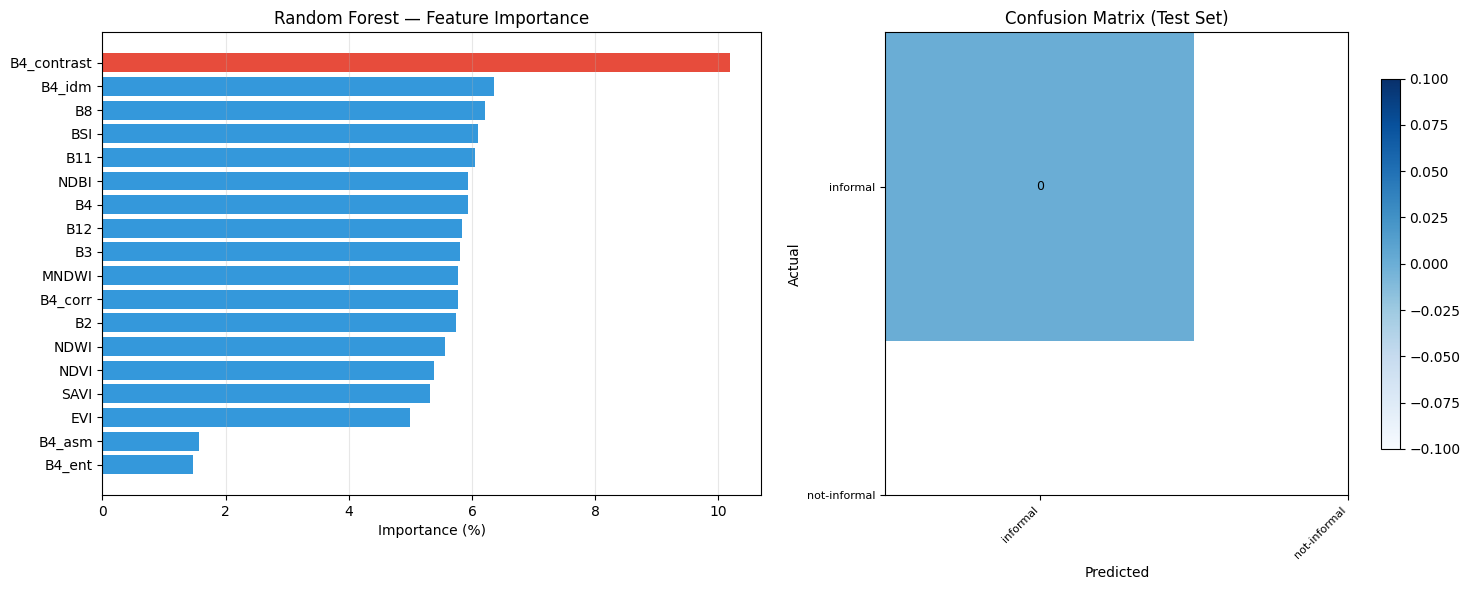

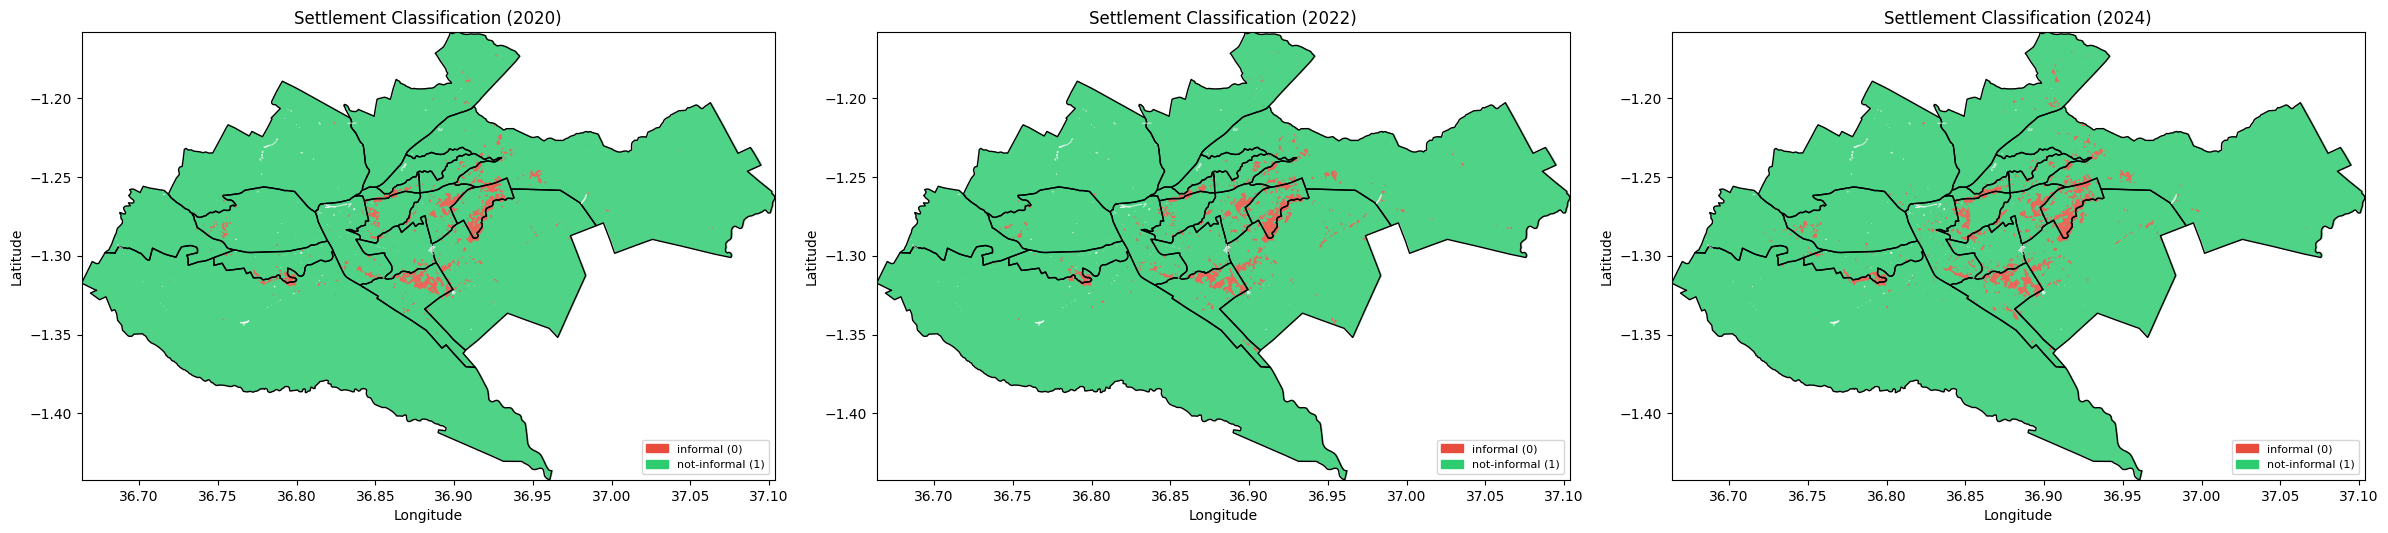


Pipeline complete!


In [4]:
results = run_pipeline(
    roi=nairobi_boundary,
    training_year=TRAINING_YEAR,
    target_years=TARGET_YEARS,
    geojson_path=TRAINING_GEOJSON,
    roads_path='../data/geospatial/adaptivity/major_roads.geojson',  
    n_trees=N_TREES,
    cloud_pct=CLOUD_PCT,
    show_plots=True,
)

---
## 4 - Detailed Accuracy Report

**Key metrics:**
- **Overall Accuracy**: % of correctly classified pixels
- **Kappa**: agreement adjusted for chance (>0.6 = substantial, >0.8 = excellent)
- **Producer's Accuracy**: per-class recall
- **Consumer's Accuracy**: per-class precision

In [5]:
metrics = results['metrics']

print('═' * 50)
print(f"  Overall Accuracy : {metrics['overall_accuracy']:.4f}")
print(f"  Kappa Coefficient: {metrics['kappa']:.4f}")
print('═' * 50)

pa = metrics.get('producers_accuracy', [[]])
ca = metrics.get('consumers_accuracy', [[]])

print('\n  Per-class metrics:')
for i, name in enumerate(CLASS_NAMES):
    try:
        prod = pa[i][0] if i < len(pa) else 'N/A'
        cons = ca[0][i] if i < len(ca[0]) else 'N/A'
        if isinstance(prod, float): prod = f'{prod:.3f}'
        if isinstance(cons, float): cons = f'{cons:.3f}'
        print(f"    {name:12s}  Producer: {prod}  |  Consumer: {cons}")
    except:
        print(f"    {name:12s}  (metrics not available)")

══════════════════════════════════════════════════
  Overall Accuracy : 0.0000
  Kappa Coefficient: 0.0000
══════════════════════════════════════════════════

  Per-class metrics:
    informal      Producer: 0  |  Consumer: 0
    not-informal  Producer: N/A  |  Consumer: N/A


---
## 5 - Classify a Custom Year

The trained classifier is reusable. Just build a new composite and classify:

Building composite for 2019...
  [Loading Sentinel-2 composite for 2019]
  [Computing spectral indices]
  [Computing GLCM texture features]
Classifying 2019...
Failed to plot roads: ../data/geospatial/major_roads.geojson: No such file or directory


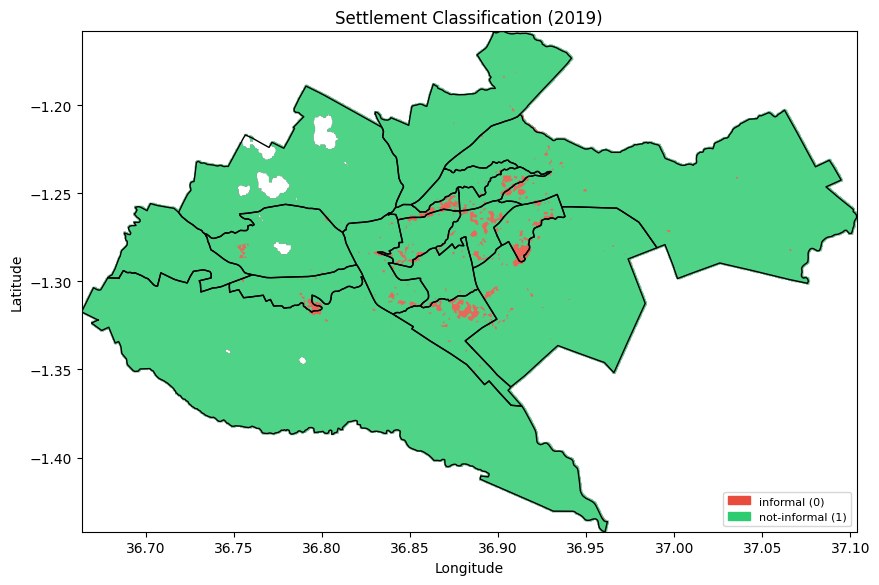

In [6]:
CUSTOM_YEAR = 2019

print(f'Building composite for {CUSTOM_YEAR}...')
composite_custom = build_feature_composite(nairobi_boundary, CUSTOM_YEAR)

print(f'Classifying {CUSTOM_YEAR}...')
classified_custom = classify_image(composite_custom, results['classifier'])

fig, ax = plt.subplots(figsize=(10, 8))
visualize_classification(
    classified_custom, 
    nairobi_boundary, 
    ax=ax, 
    year=CUSTOM_YEAR, 
    roads_path='../data/geospatial/major_roads.geojson'  
)
plt.show()


---
---
## 6 - How to Improve Accuracy

### 1. Better Training Data (MOST IMPORTANT)
- Open `data/geospatial/training_zones_template.geojson` in [geojson.io](https://geojson.io)
- Draw **precise, irregular** polygons following real boundaries (not squares!)
- **Bigger polygons** = more training pixels = better
- Add more zones per class, especially for under-represented classes
- Set `TRAINING_GEOJSON = '../data/geospatial/my_zones.geojson'`
- Only train on specific season and not the full year this will allow to have the same type of colors.

### 2. Existing Datasets
- **Map Kibera / OpenStreetMap** - community-mapped slum boundaries,  *Map Kibera* do not exist anymore and *OpenStreetMap* classification is not really existing.
- [**SDI Dataset**](https://sdinet.org/explore-our-data/): this is quite hard to extract the informations from it.
- **IDEAMAPS Network** - curated informal settlement reference data

### 3. Model Tuning
- Try `N_TREES = 500` for better accuracy (slower)
- Fall back to binary (informal vs. not-informal), right now 3 classes still noisy

### Personal Conclusion
When searching for a map representing informal settlements we find this, we can see that our map over detect (Improving idea: finetune parameters of the filtering function and use the temperature as an indicator).

<img src="..\data\images\informal_settlements.png" width="100%">

In [ ]:
print("Extracting Informal Settlements for 2024...")
classified_img = results["classified"][2024]

# 1. Filter for class 0 (informal)
informal_mask = classified_img.eq(0)

# 2. Vectorize the informal settlements
vectors = informal_mask.updateMask(informal_mask).reduceToVectors(
    geometry=nairobi_boundary,
    scale=30,
    geometryType='polygon',
    eightConnected=False,
    maxPixels=1e9
)

# 3. Get LST Image for 2024 (Dry Season: June-September) to attach mean LST
lst_2024 = ee.ImageCollection("MODIS/061/MOD11A1") \
    .filterBounds(nairobi_boundary) \
    .filterDate("2024-06-01", "2024-09-30") \
    .select("LST_Day_1km") \
    .mean() \
    .multiply(0.02) \
    .subtract(273.15)

# 4. Reduce LST and Area over the vectors
def add_lst_and_area(feature):
    mean_lst = lst_2024.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=feature.geometry(),
        scale=30,
        maxPixels=1e9
    ).get('LST_Day_1km')
    area_sqm = feature.geometry().area(1)
    return feature.set('mean_lst', mean_lst).set('area_sqm', area_sqm)

print("Calculating Mean LST and Area per polygon (this may take a minute)...")
informal_with_lst = vectors.map(add_lst_and_area)

# 5. Export to GeoJSON
geojson_data = informal_with_lst.getInfo()
gdf = gpd.GeoDataFrame.from_features(geojson_data)
gdf.set_crs(epsg=4326, inplace=True)

output_path = '../webapp/public/maps/informal_settlements.geojson'
gdf.to_file(output_path, driver='GeoJSON')
print(f"Successfully exported {len(gdf)} settlements to {output_path}")


Extracting Informal Settlements for 2024...
Calculating Mean LST and Area per polygon (this may take a minute)...
Successfully exported 1146 settlements to ../webapp/public/maps/informal_settlements.geojson
